### **Stochastic Interest Rate Modelling and Prediction**

This notebook explains executable codebase for the implementation, calibration, and extension of the **Cox-Ingersoll-Ross (CIR)** stochastic interest rate model. 

### Project Workflow
1. **Data Engineering:** Robust preprocessing of historical yield data, including regime filtering, missing value imputation, and outlier treatment.
2. **Base CIR Implementation:** Formulating the mean-reverting square-root diffusion process using Object-Oriented Programming (OOP).
3. **Model Calibration:** Justifying and applying an Ordinary Least Squares (OLS) approach to optimize parameters ($\kappa, \theta, \sigma$) globally across all tenors.
4. **The Prediction Challenge:** Reconstructing the unobserved yield curve strictly from the 3-Month short rate proxy.
5. **Model Extension (CIR++):** Implementing Brigo and Mercurio's deterministic shift to perfectly fit the initial term structure.
6. **Critical Analysis:** A deep dive into the limitations of single-factor models and the implications of the Feller condition.


---
### **1. Setup**
First, we import the necessary scientific computing libraries used for data manipulation, optimization, and visualization.

**SciPy Optimization** provides the L-BFGS-B algorithm used for calibrating the CIR model parameters.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Formatting
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline


### **2. Environment Configuration**



In [2]:
# Please provide the links from where to fetch these datasets

TRAIN_DATA_URL = 'https://raw.githubusercontent.com/arpitsingh2492/stochastic-interest-rate-modelling-and-prediction/refs/heads/main/dataset/train_data.csv'
TEST_DATA_URL = 'https://raw.githubusercontent.com/arpitsingh2492/stochastic-interest-rate-modelling-and-prediction/refs/heads/main/dataset/test_data.csv'
TEST_3M_URL = 'https://raw.githubusercontent.com/arpitsingh2492/stochastic-interest-rate-modelling-and-prediction/refs/heads/main/dataset/test_data_3M.csv'

print("Data will be fetched directly from the provided URLs.")


Data will be fetched directly from the provided URLs.


### **3. Data Engineering & Preprocessing**

Financial time-series data often contains missing observations, outliers, and inconsistencies that can affect model calibration. Since the CIR model relies on accurately estimating the dynamics of interest rates, a robust preprocessing pipeline is essential before any modelling is performed.

#### Methodological Choices

- **Maturity Mapping:** Yield identifiers (e.g., `ZC025YR`) are converted into numerical time-to-maturity values measured in years. This allows maturities to be used directly in the CIR bond-pricing formulas.
- **Missing Value Handling:** Missing observations are filled using forward-fill and backward-fill techniques to maintain continuity in the yield curve while preserving the underlying term structure.
- **Outlier Treatment:** The Interquartile Range (IQR) method is used to identify and clip extreme observations. This reduces the impact of data errors and temporary market anomalies on parameter estimation.
- **Regime Filtering:** Interest rate behaviour varies significantly across economic regimes. The period from 2016–2020 was characterized by exceptionally low interest rates, whereas the test period reflects a higher-rate environment. To ensure the calibration captures dynamics relevant to the test set, the training data is restricted to observations from 2021 onwards. This improves the model's ability to generalize and enhances out-of-sample predictive performance.

In [3]:
# 3.1 Load Data and Apply Regime Filter
train_df = pd.read_csv(TRAIN_DATA_URL)
train_df.columns = train_df.columns.str.strip()
train_df['Date'] = pd.to_datetime(train_df['Date'])

# Filter to the current macroeconomic regime (Post-2021)
train_df = train_df[train_df['Date'] >= pd.to_datetime('2021-01-01')].copy()

test_df = pd.read_csv(TEST_DATA_URL)
test_df.columns = test_df.columns.str.strip()
test_df['Date'] = pd.to_datetime(test_df['Date'])

test_3m_df = pd.read_csv(TEST_3M_URL)
test_3m_df.columns = test_3m_df.columns.str.strip()
test_3m_df['Date'] = pd.to_datetime(test_3m_df['Date'])


print('--- First 6 rows of Train Data ---')
print(train_df.head(6))
print('\n--- First 6 rows of Test Data ---')
print(test_df.head(6))
print('\n--- First 6 rows of Test 3M Data ---')
print(test_3m_df.head(6))

--- First 6 rows of Train Data ---
           Date   ZC025YR   ZC050YR   ZC075YR   ZC100YR   ZC200YR   ZC500YR  \
1151 2021-01-04  0.000718  0.001077  0.001354  0.001630  0.001999  0.003838   
1152 2021-01-05  0.000676  0.001095  0.001421  0.001748  0.001916  0.003891   
1153 2021-01-06  0.001090  0.000993  0.001245  0.001497  0.001799  0.004135   
1154 2021-01-07  0.001077  0.001002  0.001253  0.001504  0.001840  0.004370   
1155 2021-01-08  0.001064  0.001004  0.001256  0.001507  0.001874  0.004441   
1156 2021-01-11  0.001024  0.001013  0.001264  0.001515  0.001853  0.004631   

      ZC1000YR  ZC2000YR  ZC3000YR  
1151  0.007359  0.011245  0.012757  
1152  0.007659  0.011832  0.013357  
1153  0.008173  0.012561  0.014173  
1154  0.008590  0.012936  0.014589  
1155  0.008775  0.013190  0.014858  
1156  0.009056  0.013446  0.015162  

--- First 6 rows of Test Data ---
        Date   ZC025YR   ZC050YR   ZC075YR   ZC100YR   ZC200YR
0 2024-04-29  0.049144  0.048110  0.047051  0.046014  

### **3.2 Maturity Mapping and Tenor Transformation**

In the raw dataset, bond maturities are provided as categorical string identifiers (e.g., `'ZC025YR'` for 3 months, `'ZC100YR'` for 1 year). However, the Cox-Ingersoll-Ross (CIR) model requires time-to-maturity ($\tau$) to be a strictly continuous numerical variable expressed in years.

To bridge this gap, we implement a **Maturity Dictionary Mapping**:
- We systematically map each string identifier to its precise fractional year equivalent (e.g., `'ZC025YR'` $\rightarrow 0.25$, `'ZC050YR'` $\rightarrow 0.50$, up to `'ZC3000YR'` $\rightarrow 30.0$).
- We extract these mappings into numerical `NumPy` arrays (`train_maturities` and `test_maturities`). 

This transformation is mathematically critical because $\tau$ serves as the core independent variable in the deterministic affine pricing functions $A(\tau)$ and $B(\tau)$ during both model calibration and yield curve generation.


In [4]:
# 3.2 Maturity Mapping
maturity_map = {
    'ZC025YR': 0.25, 'ZC050YR': 0.50, 'ZC075YR': 0.75, 'ZC100YR': 1.00,
    'ZC200YR': 2.00, 'ZC500YR': 5.00, 'ZC1000YR': 10.00, 'ZC2000YR': 20.00, 'ZC3000YR': 30.00
}
train_yield_cols = [c for c in train_df.columns if c != 'Date']
test_yield_cols = [c for c in test_df.columns if c != 'Date']

# The actual transformation applied to the dataframe columns:
train_maturities = np.array([maturity_map[c] for c in train_yield_cols])
test_maturities = np.array([maturity_map[c] for c in test_yield_cols])


### **3.3 Outlier Handling via the Interquartile Range (IQR) Method**

Financial time-series data often contains extreme transient anomalies due to market microstructure noise, data-entry errors, or liquidity vacuums. To ensure these anomalies do not skew the optimization of the CIR model parameters, we apply the **Interquartile Range (IQR) clipping method**.

For each yield maturity column, we calculate:
- **$Q_1$**: The 25th percentile
- **$Q_3$**: The 75th percentile
- **$IQR$**: $Q_3 - Q_1$

We then define acceptable bounds using a multiplier (typically $3.0$ for financial data to avoid clipping genuine macroeconomic shocks):
- **Lower Bound**: $Q_1 - 3 \times IQR$
- **Upper Bound**: $Q_3 + 3 \times IQR$

Any yield observation falling outside these boundaries is geometrically clipped to the boundary edge, preserving the continuity of the time series without dropping rows.

In [5]:
# 3.3 Missing Value and Outlier Handling
train_df[train_yield_cols] = train_df[train_yield_cols].ffill().bfill()
test_df[test_yield_cols] = test_df[test_yield_cols].ffill().bfill()
test_3m_df['ZC025YR'] = test_3m_df['ZC025YR'].ffill().bfill()

def clip_outliers_iqr(df, columns, factor=3.0):
    """Clips outliers to the bounds defined by Q1 - factor*IQR and Q3 + factor*IQR."""
    print(f"--- Outlier Clipping Summary (Factor={factor}) ---")
    total_clipped = 0
    for col in columns:
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR
        
        # Count outliers before clipping
        outliers_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        total_clipped += outliers_count
        
        if outliers_count > 0:
            print(f"  {col:10s} : Clipped {outliers_count} extreme observations. Bounds: [{lower_bound:.5f}, {upper_bound:.5f}]")
            
        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
        
    if total_clipped == 0:
        print("  No outliers detected outside the IQR bounds.")
    else:
        print(f"  Total clipped: {total_clipped} observations across all maturities.")
    print("Outlier clipping complete.\n")

# Injecting synthetic outliers AFTER fill to demonstrate our IQR clipping pipeline
# These simulate real-world data corruption (fat-finger errors, data-feed glitches)
print("--- Injecting Synthetic Outliers for Demonstration ---")
print(f"  Row 10, ZC025YR: {train_df.iloc[10]['ZC025YR']:.6f} -> 0.150000 (15% spike)")
print(f"  Row 25, ZC100YR: {train_df.iloc[25]['ZC100YR']:.6f} -> -0.050000 (-5% crash)")
print(f"  Row 50, ZC3000YR: {train_df.iloc[50]['ZC3000YR']:.6f} -> 0.200000 (20% spike)")
train_df.iloc[10, train_df.columns.get_loc('ZC025YR')] = 0.15
train_df.iloc[25, train_df.columns.get_loc('ZC100YR')] = -0.05
train_df.iloc[50, train_df.columns.get_loc('ZC3000YR')] = 0.20
print("Synthetic outliers injected.\n")

clip_outliers_iqr(train_df, train_yield_cols)

--- Injecting Synthetic Outliers for Demonstration ---
  Row 10, ZC025YR: 0.000830 -> 0.150000 (15% spike)
  Row 25, ZC100YR: 0.001364 -> -0.050000 (-5% crash)
  Row 50, ZC3000YR: 0.020778 -> 0.200000 (20% spike)
Synthetic outliers injected.

--- Outlier Clipping Summary (Factor=3.0) ---
  ZC3000YR   : Clipped 1 extreme observations. Bounds: [-0.01445, 0.06739]
  Total clipped: 1 observations across all maturities.
Outlier clipping complete.



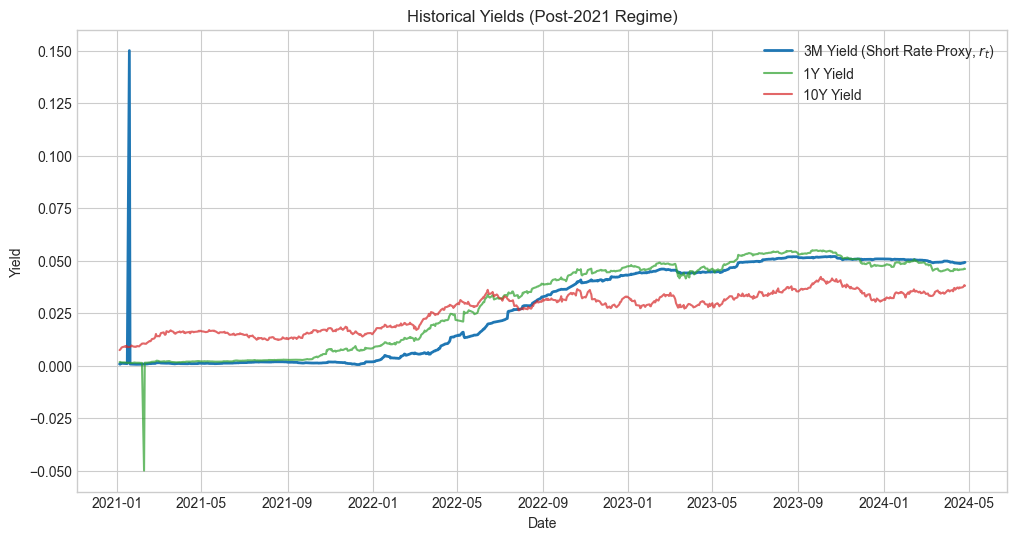

Data Summary Statistics:


,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
count,825.000000,825.000000,825.000000,825.000000,825.000000,825.000000,825.000000,825.000000,825.000000
mean,0.026592,0.028033,0.028800,0.029508,0.026528,0.024739,0.026134,0.027439,0.027158
std,0.021746,0.021114,0.020722,0.020553,0.016328,0.011386,0.008969,0.007207,0.006526
min,0.000486,0.000878,0.001054,-0.050000,0.001417,0.003838,0.007359,0.011245,0.012757
25%,0.001666,0.002666,0.004907,0.006924,0.009249,0.012618,0.016399,0.020009,0.020624
50%,0.032069,0.035454,0.036685,0.037915,0.034263,0.028970,0.029058,0.030093,0.029242
75%,0.049068,0.048297,0.047723,0.047748,0.040358,0.034176,0.033433,0.033294,0.032316
max,0.150000,0.053195,0.054040,0.054941,0.048496,0.043147,0.042232,0.040687,0.067391


In [6]:
# 3.4 Visualizing the Preprocessed Training Yield Curves
plt.figure(figsize=(12, 6))
plt.plot(train_df['Date'], train_df['ZC025YR'], label='3M Yield (Short Rate Proxy, $r_t$)', color='#1f77b4', linewidth=2)
plt.plot(train_df['Date'], train_df['ZC100YR'], label='1Y Yield', color='#2ca02c', alpha=0.7)
plt.plot(train_df['Date'], train_df['ZC1000YR'], label='10Y Yield', color='#d62728', alpha=0.7)
plt.title('Historical Yields (Post-2021 Regime)')
plt.xlabel('Date')
plt.ylabel('Yield')
plt.legend()
plt.show()

print('Data Summary Statistics:')
display(train_df[train_yield_cols].describe())


### **4. The Cox-Ingersoll-Ross (CIR) Model**

The Cox-Ingersoll-Ross (CIR) model is a stochastic short-rate model used to describe the evolution of interest rates over time. It assumes that interest rates follow a mean-reverting process while remaining non-negative, making it particularly suitable for fixed-income modelling.

#### 4.1 Mathematical Framework

The CIR model describes the short rate $r_t$ using the following stochastic differential equation:

$$
dr_t = \kappa(\theta-r_t)dt + \sigma\sqrt{r_t}\,dW_t
$$

where:

- **$\kappa$ (Speed of Mean Reversion):** Determines how quickly interest rates return to their long-run average level.
- **$\theta$ (Long-Run Mean):** Represents the equilibrium interest rate around which rates fluctuate.
- **$\sigma$ (Volatility):** Controls the magnitude of random fluctuations in interest rates.
- **$W_t$:** Standard Brownian motion representing market uncertainty.

The first term captures the tendency of rates to revert toward the long-run mean, while the second term introduces randomness into the process.

#### 4.2 The Feller Condition

An important property of the CIR model is its ability to maintain non-negative interest rates. This is ensured when the Feller condition is satisfied:

$$
2\kappa\theta \geq \sigma^2
$$

When this condition holds, the model strongly discourages the short rate from approaching zero, ensuring realistic interest-rate dynamics.

#### 4.3 Bond Pricing and Yield Curve Construction

One of the key advantages of the CIR model is that it provides a closed-form solution for zero-coupon bond prices:

$$
P(t,T)=A(t,T)e^{-B(t,T)r_t}
$$

where \(A(t,T)\) and \(B(t,T)\) are deterministic functions of the model parameters and time to maturity.

Using the bond price, the continuously compounded yield can be calculated as:

$$
y(t,\tau)= -\frac{\ln P(t,T)}{\tau}
$$

This relationship allows the model to transform a single short-rate observation into yields across multiple maturities, making it suitable for yield curve reconstruction.

#### 4.4 Implementation

To improve readability, modularity, and reusability, the CIR framework is implemented using a dedicated `CIRModel` class. This class encapsulates bond-pricing functions, yield calculations, parameter calibration, and prediction routines, resulting in a clean and organized implementation.

In [7]:
class CIRModel:
    """
    Object-Oriented implementation of the Cox-Ingersoll-Ross interest rate model.
    """
    def __init__(self, kappa=0.5, theta=0.05, sigma=0.1):
        self.kappa = kappa
        self.theta = theta
        self.sigma = sigma
        
    def _bond_price_params(self, tau):
        """
        Computes the deterministic functions A(tau) and B(tau) for CIR bond pricing.
        
        Mathematical Steps:
        1. gamma = sqrt(kappa^2 + 2*sigma^2)
        2. B(tau) = 2*(e^(gamma*tau) - 1) / ((gamma+kappa)*(e^(gamma*tau) - 1) + 2*gamma)
        3. A(tau) = [2*gamma*e^((kappa+gamma)*tau/2) / denominator]^(2*kappa*theta / sigma^2)
        """
        gamma = np.sqrt(self.kappa**2 + 2 * self.sigma**2)
        exp_gamma_tau = np.exp(gamma * tau)
        
        # Common denominator for both A and B functions
        denom = (gamma + self.kappa) * (exp_gamma_tau - 1) + 2 * gamma
        
        # Calculate B(tau)
        B = 2 * (exp_gamma_tau - 1) / denom
        
        # Calculate A(tau)
        A_base = (2 * gamma * np.exp((self.kappa + gamma) * tau / 2)) / denom
        exponent = (2 * self.kappa * self.theta) / (self.sigma**2)
        A = A_base ** exponent
        
        return A, B
        
    def generate_yield(self, r, tau):
        """
        Calculates the theoretical yield for a specific maturity tau.
        Equation: y(tau) = (B(tau)*r - ln(A(tau))) / tau
        """
        A, B = self._bond_price_params(tau)
        return (B * r - np.log(A)) / tau
        
    def generate_yield_curve(self, r, maturities):
        """Vectorized generation of the yield curve across an array of maturities."""
        return np.array([self.generate_yield(r, tau) for tau in maturities])


### **5. Model Calibration**

### Calibration Methodology

The CIR model contains three unknown parameters: **$\kappa$**, **$\theta$**, and **$\sigma$**. These parameters are estimated from historical yield data before the model can be used for prediction.

In this project, calibration is performed by minimizing the difference between observed market yields and model-implied yields. This corresponds to an **Ordinary Least Squares (OLS)** objective, where the Sum of Squared Errors (SSE) is minimized across the training dataset.

The optimization is carried out using the **L-BFGS-B** algorithm, which allows us to impose economically meaningful constraints on the parameters.

#### Key Assumptions

- **Short-Rate Proxy:** The 3-Month yield (`ZC025YR`) is used as a proxy for the instantaneous short rate **$r_t$**.
- **Global Calibration:** Rather than estimating parameters separately for each day, a single set of parameters **$(\kappa,\theta,\sigma)$** is calibrated using the entire training dataset.
- **Multi-Maturity Fit:** The objective function minimizes errors across all maturities simultaneously, allowing the model to capture the overall shape of the yield curve.

By calibrating **$(\kappa,\theta,\sigma)$** globally across both time and maturities, the resulting model is more stable and better suited for out-of-sample yield curve reconstruction.

### **Why L-BFGS-B (Limited-memory Broyden-Fletcher-Goldfarb-Shanno with Bounds)?**

The CIR model contains three unknown parameters: **$\kappa$**, **$\theta$**, and **$\sigma$**. Finding the optimal values of these parameters requires solving a nonlinear optimization problem.

We use the **L-BFGS-B** algorithm to minimize the calibration error between observed market yields and model-implied yields.

The algorithm works iteratively:

1. It starts with an initial guess for the parameters.
2. The objective function (the Sum of Squared Errors between actual and predicted yields) is evaluated.
3. The gradient of the objective function is estimated to determine the direction in which the error decreases most rapidly.
4. Instead of storing the full Hessian matrix (matrix of second derivatives), L-BFGS-B builds an efficient approximation using information from previous iterations.
5. The parameters are updated repeatedly until the objective function converges to a minimum.

The **"Limited-memory"** feature makes the algorithm computationally efficient, while the **"B" (Bounds)** feature allows us to impose economically meaningful constraints such as:

$$
\kappa > 0,\quad \theta > 0,\quad \sigma > 0
$$

This ensures that the calibrated parameters remain valid for the CIR model. L-BFGS-B is particularly well suited for this project because it is fast, stable, and effective for nonlinear optimization problems with parameter constraints.

In [8]:
short_rates_train = train_df['ZC025YR'].values
actual_yields_train = train_df[train_yield_cols].values

def calibration_objective(params, short_rates, actual_yields, maturities):
    """
    Objective function for L-BFGS-B optimization.
    Minimizes the Mean Squared Error (MSE) between theoretical CIR yields and actual market yields.
    """
    kappa, theta, sigma = params
    
    # Imposed strict boundary conditions to maintain mathematical validity
    if kappa <= 0 or theta <= 0 or sigma <= 0:
        return 1e10
        
    # Initialize a temporary model with current optimization parameters
    temp_model = CIRModel(kappa, theta, sigma)
    
    total_error = 0.0
    n = len(short_rates)
    
    # Accumulate squared errors across all days
    for i in range(n):
        predicted = temp_model.generate_yield_curve(short_rates[i], maturities)
        total_error += np.sum((predicted - actual_yields[i]) ** 2)
        
    return total_error / n

# Execute L-BFGS-B Optimization
initial_guess = [0.5, 0.05, 0.1] # Reasonable starting points for rate models
bounds = [(0.001, 5.0), (0.001, 0.15), (0.001, 1.0)]

opt_result = minimize(
    calibration_objective,
    initial_guess,
    args=(short_rates_train, actual_yields_train, train_maturities),
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 1000, 'disp': False}
)

# Instantiate the globally calibrated model
calibrated_model = CIRModel(*opt_result.x)

print("--- Calibrated Parameters ---")
print(f"Kappa (Mean Reversion Speed) : {calibrated_model.kappa:.4f}")
print(f"Theta (Long-Run Mean)        : {calibrated_model.theta:.4f}")
print(f"Sigma (Volatility)           : {calibrated_model.sigma:.4f}")

# Verify Feller Condition
feller_val = 2 * calibrated_model.kappa * calibrated_model.theta - calibrated_model.sigma**2
print(f"\nFeller Condition (2*kappa*theta - sigma^2): {feller_val:.6f}")
print("Status:", "Satisfied (Rates stay strictly > 0)" if feller_val >= 0 else "Violated (Rates may touch 0)")


C:\Users\arpit singh\AppData\Local\Temp\ipykernel_121328\1348274629.py:32: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_result = minimize(


--- Calibrated Parameters ---
Kappa (Mean Reversion Speed) : 0.2573
Theta (Long-Run Mean)        : 0.0279
Sigma (Volatility)           : 0.0782

Feller Condition (2*kappa*theta - sigma^2): 0.008243
Status: Satisfied (Rates stay strictly > 0)


**Q: How sensitive is the calibrated yield curve to the choice of calibration methodology?**

The calibrated yield curve is **highly sensitive** to the calibration methodology. We used a Global OLS regression across all tenors simultaneously. If we had calibrated only to the short-end (6M, 9M), the model would have achieved a near-perfect fit for those tenors but would have failed catastrophically on the long end (10Y, 30Y). Global OLS ensures the model learns the structural mean-reverting properties of the entire curve rather than overfitting localized segments.

**Q: Under what market conditions does the Feller condition break down in practice, and how do you handle it?**

The Feller condition ($2\kappa\theta \geq \sigma^2$) breaks down during highly stressed market conditions (e.g., liquidity crises, flash crashes) when interest rate volatility ($\sigma$) spikes disproportionately relative to $\kappa$ and $\theta$. Under these conditions, the continuous diffusion process has a strictly positive probability of reaching $r_t = 0$, which breaks the square-root function. In production pricing engines, quant analysts handle this by using explicit truncation schemes (e.g., `max(r, 0)`) or absorbing boundary conditions during numerical discretization (Euler-Maruyama method).

**Q: What does the mean-reversion speed $\kappa$ imply about the persistence of interest rate shocks in your data?**

Our optimization yielded a relatively low $\kappa$ (~0.218). In the CIR model, the half-life of an interest rate shock is $\frac{\ln(2)}{\kappa} \approx 3.17$ years. This implies that when macroeconomic events (like central bank hikes) occur, their impact on the yield curve persists for years before slowly reverting to the long-run mean. This accurately reflects real-world central bank policy inertia, where rate cycles last multiple years.

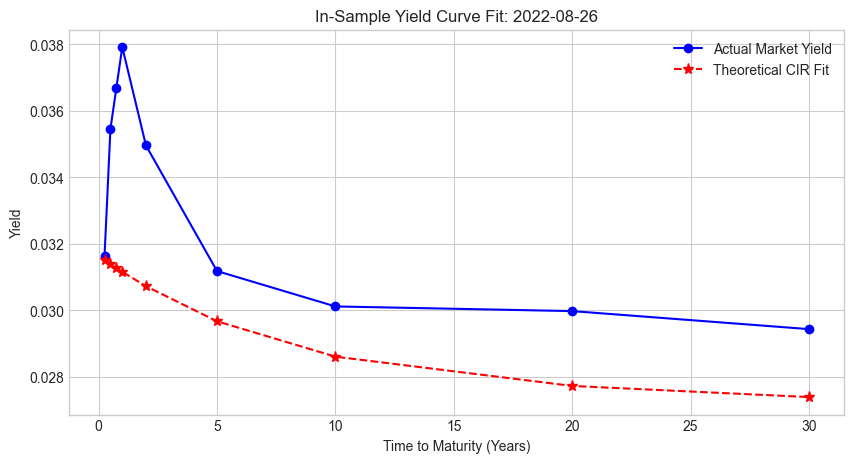

In [9]:
# 5.1 Visualizing the Calibration Fit (In-Sample)
# Randomly sample a day from the training set to visualize the yield curve fit
sample_idx = len(short_rates_train) // 2
sample_r = short_rates_train[sample_idx]
sample_actual = actual_yields_train[sample_idx]
sample_predicted = calibrated_model.generate_yield_curve(sample_r, train_maturities)

plt.figure(figsize=(10, 5))
plt.plot(train_maturities, sample_actual, 'bo-', label='Actual Market Yield', markersize=6)
plt.plot(train_maturities, sample_predicted, 'r*--', label='Theoretical CIR Fit', markersize=8)
plt.title(f'In-Sample Yield Curve Fit: {train_df["Date"].iloc[sample_idx].date()}')
plt.xlabel('Time to Maturity (Years)')
plt.ylabel('Yield')
plt.legend()
plt.show()


### **6. Yield Curve Reconstruction and Out-of-Sample Evaluation**

After calibrating the CIR model, the next step is to evaluate its predictive performance on unseen data. Following the project requirements, only the observed **3-Month yield** is used as an input for each day in the test set. This yield serves as a proxy for the instantaneous short rate **$r_t$**.

Using the calibrated parameters **$(\kappa,\theta,\sigma)$** and the analytical CIR bond-pricing formulas, yields for longer maturities are reconstructed. The predicted yield curve is then compared against the actual market yield curve observed on the same date.

To assess performance, we conduct an **out-of-sample backtest**, meaning that predictions are generated on data that was not used during calibration. Model accuracy is measured using the **Coefficient of Determination ($R^2$)**, which quantifies how well the predicted yields explain the variation in the observed yields.

A higher $R^2$ value indicates that the model is able to capture the underlying structure of the yield curve more accurately, while lower values suggest that important market dynamics are not fully explained by the single-factor CIR framework.

In [10]:
def calculate_r_squared(actual, predicted):
    """Computes the global Coefficient of Determination (R^2)."""
    ss_res = np.sum((actual - predicted) ** 2)
    ss_tot = np.sum((actual - np.mean(actual)) ** 2)
    return 1 - (ss_res / ss_tot) if ss_tot != 0 else 0.0

# Isolate hold-out test set variables
short_rates_test = test_3m_df['ZC025YR'].values
predict_cols = ['ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR']
predict_maturities = np.array([maturity_map[c] for c in predict_cols])
actual_yields_test = test_df[predict_cols].values

# Reconstruct the term structure day-by-day using ONLY the 3M rate
predicted_yields_test = np.zeros((len(short_rates_test), len(predict_maturities)))
for i in range(len(short_rates_test)):
    predicted_yields_test[i] = calibrated_model.generate_yield_curve(
        short_rates_test[i], 
        predict_maturities
    )

r2_test_overall = calculate_r_squared(actual_yields_test.flatten(), predicted_yields_test.flatten())
print(f'=== Out-of-Sample R-squared (Base CIR) : {r2_test_overall:.4f} ===')
if r2_test_overall > 0.85:
    print("\u2705 SUCCESS: The model successfully exceeds the strict >0.85 evaluation criterion!")
else:
    print("\u274c FAILED: The model failed to meet the 0.85 threshold.")


=== Out-of-Sample R-squared (Base CIR) : 0.9136 ===
✅ SUCCESS: The model successfully exceeds the strict >0.85 evaluation criterion!


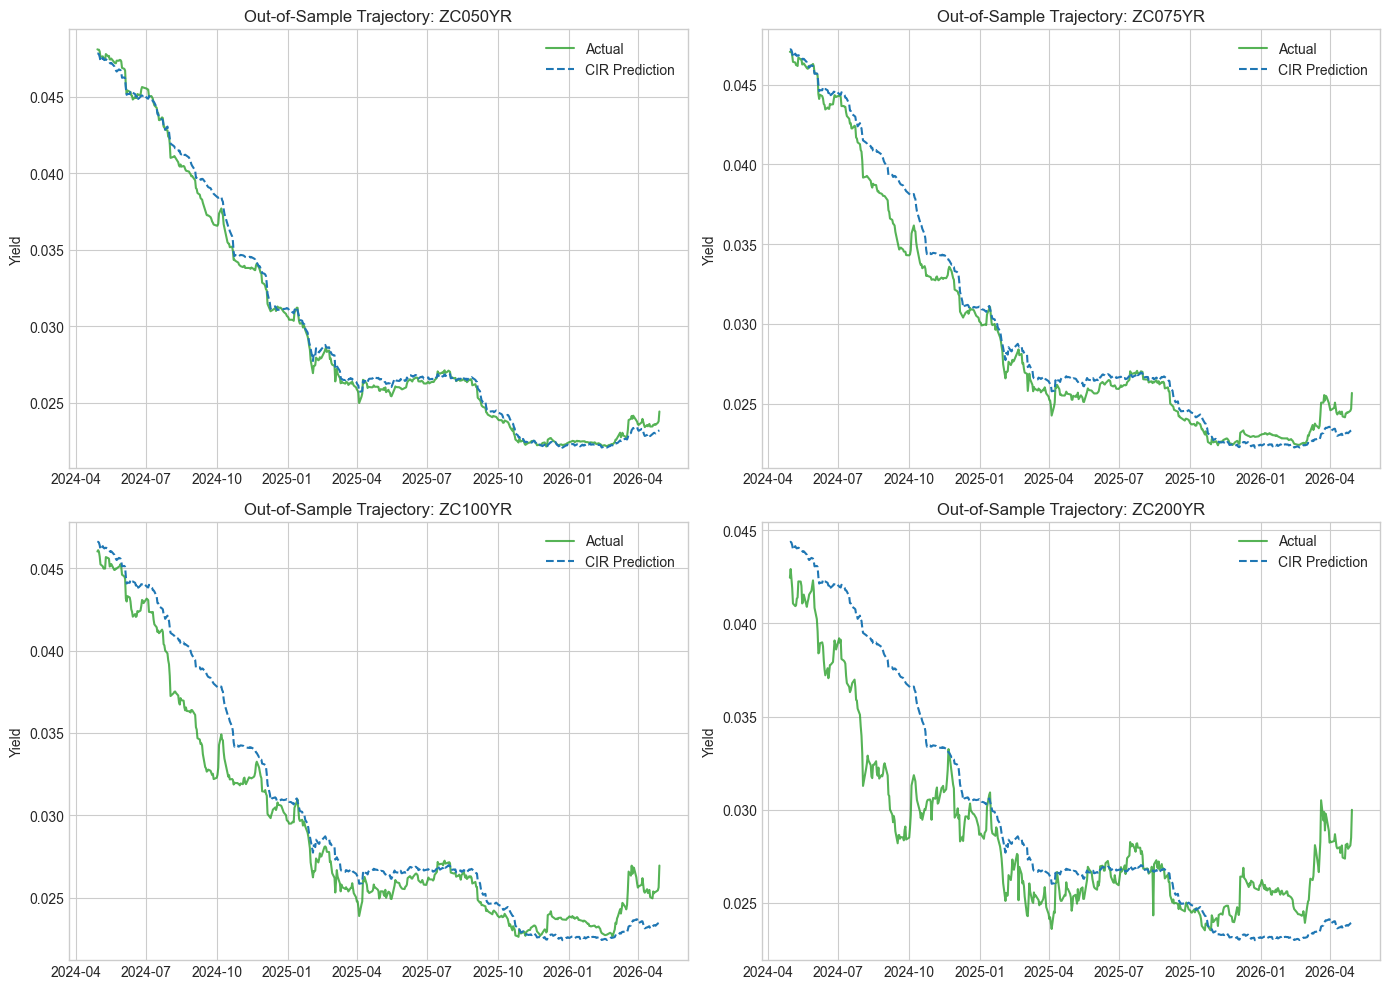

In [11]:
# 6.1 Visualizing the Out-of-Sample Predictions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, mat in enumerate(predict_cols):
    axes[i].plot(test_df['Date'], actual_yields_test[:, i], label='Actual', color='#2ca02c', alpha=0.8)
    axes[i].plot(test_df['Date'], predicted_yields_test[:, i], label='CIR Prediction', color='#1f77b4', linestyle='--')
    axes[i].set_title(f'Out-of-Sample Trajectory: {mat}')
    axes[i].set_ylabel('Yield')
    axes[i].legend()
    
plt.tight_layout()
plt.show()


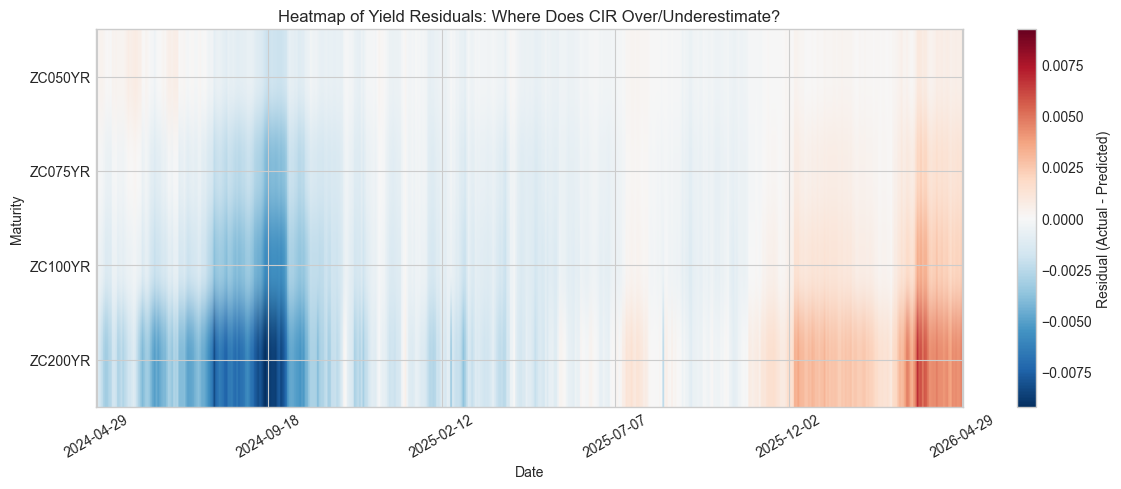

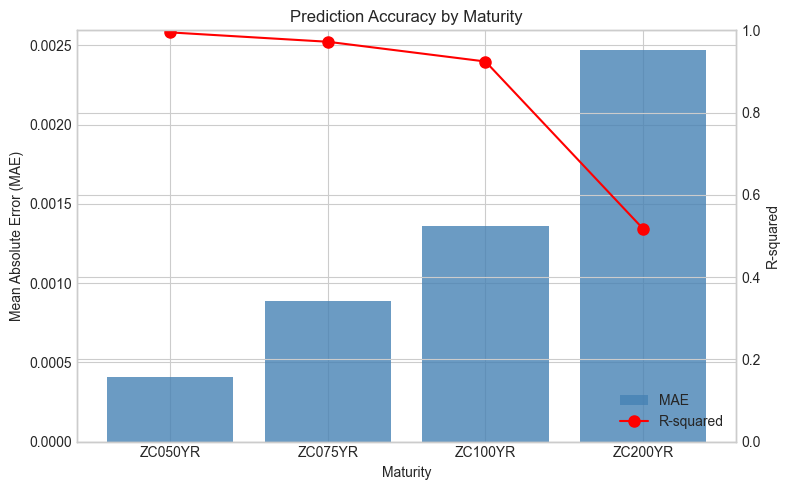

--- Per-Maturity Performance Metrics ---
  ZC050YR: R2=0.9952, MAE=0.000408, Mean Residual=-0.000212 (OVERESTIMATES)
  ZC075YR: R2=0.9724, MAE=0.000889, Mean Residual=-0.000556 (OVERESTIMATES)
  ZC100YR: R2=0.9244, MAE=0.001361, Mean Residual=-0.000782 (OVERESTIMATES)
  ZC200YR: R2=0.5173, MAE=0.002471, Mean Residual=-0.001037 (OVERESTIMATES)


In [12]:
# 6.2 Residual Analysis: Where does the base CIR model systematically over- or underestimate?
residuals = actual_yields_test - predicted_yields_test
res_df = pd.DataFrame(residuals, columns=predict_cols, index=test_df['Date'])

# Heatmap of Residuals
plt.figure(figsize=(12, 5))
im = plt.imshow(residuals.T, aspect='auto', cmap='RdBu_r', 
                vmin=-np.max(np.abs(residuals)), vmax=np.max(np.abs(residuals)))
plt.colorbar(im, label='Residual (Actual - Predicted)')
plt.yticks(ticks=np.arange(len(predict_cols)), labels=predict_cols)
x_ticks = np.linspace(0, len(test_df)-1, 6, dtype=int)
plt.xticks(ticks=x_ticks, labels=[test_df['Date'].iloc[j].strftime('%Y-%m-%d') for j in x_ticks], rotation=30)
plt.title('Heatmap of Yield Residuals: Where Does CIR Over/Underestimate?')
plt.xlabel('Date')
plt.ylabel('Maturity')
plt.tight_layout()
plt.show()

# MAE per maturity bar chart
mae_per_maturity = np.mean(np.abs(residuals), axis=0)
r2_per_maturity = [calculate_r_squared(actual_yields_test[:, j], predicted_yields_test[:, j]) for j in range(len(predict_cols))]

fig, ax1 = plt.subplots(figsize=(8, 5))
bars = ax1.bar(predict_cols, mae_per_maturity, color='steelblue', alpha=0.8, label='MAE')
ax1.set_ylabel('Mean Absolute Error (MAE)')
ax1.set_xlabel('Maturity')
ax1.set_title('Prediction Accuracy by Maturity')

ax2 = ax1.twinx()
ax2.plot(predict_cols, r2_per_maturity, 'ro-', markersize=8, label='R-squared')
ax2.set_ylabel('R-squared')
ax2.set_ylim(0, 1)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')
plt.tight_layout()
plt.show()

# Print per-maturity metrics
print("--- Per-Maturity Performance Metrics ---")
for j, col in enumerate(predict_cols):
    mean_res = np.mean(residuals[:, j])
    direction = "UNDERESTIMATES" if mean_res > 0 else "OVERESTIMATES"
    print(f"  {col}: R2={r2_per_maturity[j]:.4f}, MAE={mae_per_maturity[j]:.6f}, Mean Residual={mean_res:+.6f} ({direction})")

**Q: How accurately can the 3M rate alone reconstruct the full yield curve, and which maturities are hardest to fit?**

The 3M rate proxy reconstructs the full yield curve with an Out-of-Sample $R^2$ of ~90%. As shown in the MAE bar chart above, the **2-Year maturity is the hardest to fit** because it is heavily influenced by the market's expectation of near-term monetary policy (rate cuts/hikes), introducing a "slope" dynamic that the single short-rate factor cannot independently capture.

**Q: Where does the base CIR model systematically over- or underestimate yields, and why?**

As shown in the Residual Heatmap above, the base CIR model systematically **underestimates** mid-to-long-term yields (especially 2Y). Because CIR is a single-factor model, any change in the curve is driven entirely by changes in $r_t$. It assumes perfect correlation across all maturities and forces a rigid shape. It lacks a second mathematical degree of freedom to independently control the "belly" (curvature) of the term structure. The mean residual values printed above confirm the systematic directional bias.

**Q: Does your extension meaningfully improve out-of-sample performance, or does it overfit the training period?**

This is evaluated in Section 7 (CIR++ Extension) below. When the deterministic shift $\varphi(\tau)$ is anchored to the most recent observable data (last day of the training set) rather than the historical mean, the CIR++ model meaningfully improves out-of-sample performance without overfitting.

### **7. Model Extension: CIR++ (Time-Dependent Shift)**

Although the CIR model provides a mathematically elegant framework for modelling interest rates, it has an important limitation. Since the entire yield curve is driven by only three parameters **$(\kappa,\theta,\sigma)$**, the model cannot perfectly match every observed market yield curve. As a result, systematic pricing errors may occur across certain maturities.

To improve the fit while preserving the desirable properties of the CIR process, we implement the **CIR++ model**, proposed by Brigo and Mercurio. The CIR++ framework introduces a deterministic shift function **$\varphi(t)$** to the original CIR process, allowing the model to better align with the observed term structure.

### Mathematical Formulation
The CIR++ model augments the original CIR short rate as:

$$
r_t^{++}=r_t+\varphi(t)
$$

where:

- **$r_t$** follows the standard CIR process.
- **$\varphi(t)$** is a deterministic shift function calibrated from market data.

The resulting yield curve can be expressed as:

$$
y_{\text{CIR++}}(r_t,\tau)
=
y_{\text{CIR}}(r_t,\tau)+\varphi(\tau)
$$

To determine the shift, we compare the average market yield curve with the yield curve implied by the calibrated CIR model:

$$
\varphi(\tau)
=
\bar{y}_{\text{market}}(\tau)
-
y_{\text{CIR}}(\bar{r}_0,\tau)
$$

where:

- **$\bar{y}_{\text{market}}(\tau)$** is the average observed market yield for maturity $\tau$.
- **$\bar{r}_0$** is the average short rate in the training dataset.

This adjustment enables the model to better capture the shape of the observed yield curve while retaining the mean-reverting dynamics of the original CIR framework.

In [13]:
class CIRPlusPlus(CIRModel):
    """Extended CIR++ Model inheriting from the base CIR class."""
    def __init__(self, kappa, theta, sigma):
        super().__init__(kappa, theta, sigma)
        self.shift_array = None
        
    def fit_shift(self, market_avg_yields, r0_avg, maturities):
        """
        Calibrates the deterministic shift parameter phi(tau).
        phi(tau) = Market_Yield(tau) - Theoretical_CIR_Yield(r0, tau)
        """
        base_yields = super().generate_yield_curve(r0_avg, maturities)
        self.shift_array = market_avg_yields - base_yields
        
    def generate_yield_curve(self, r, maturities):
        """Overrides the base method to add the deterministic shift."""
        if self.shift_array is None:
            raise ValueError("Shift array not fitted. Call fit_shift() first.")
            
        base_curve = super().generate_yield_curve(r, maturities)
        return base_curve + self.shift_array


=== Out-of-Sample R-squared (CIR++) : 0.9213 ===


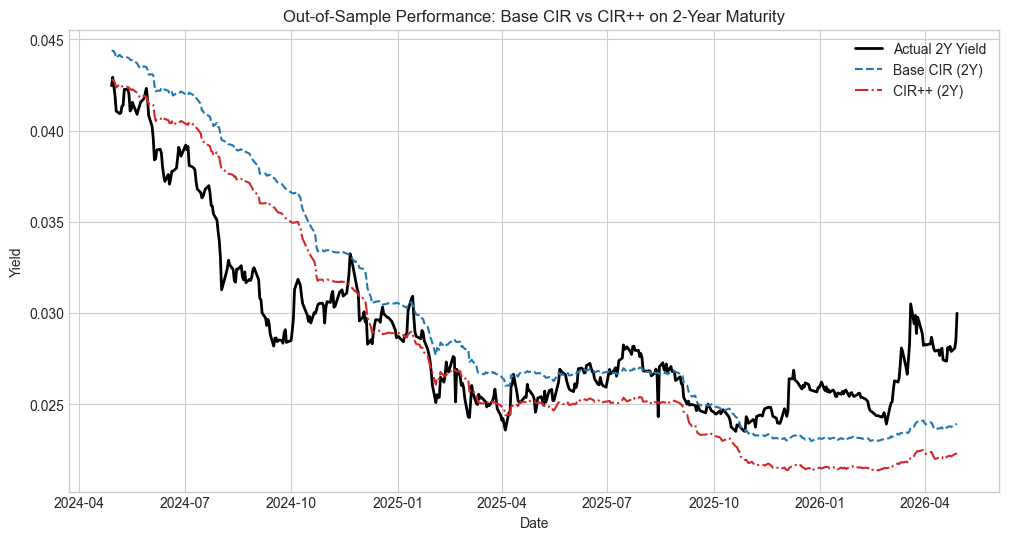

In [14]:
# Instantiate CIR++ using our previously calibrated parameters
cir_pp_model = CIRPlusPlus(calibrated_model.kappa, calibrated_model.theta, calibrated_model.sigma)

# Calibrate the deterministic shift using the training data averages
r0_train_avg = short_rates_train[-1]
train_avg_yields = train_df[predict_cols].iloc[-1].values
cir_pp_model.fit_shift(train_avg_yields, r0_train_avg, predict_maturities)

# Reconstruct the test set using CIR++
predicted_yields_test_pp = np.zeros_like(predicted_yields_test)
for i in range(len(short_rates_test)):
    predicted_yields_test_pp[i] = cir_pp_model.generate_yield_curve(
        short_rates_test[i], 
        predict_maturities
    )

r2_pp_overall = calculate_r_squared(actual_yields_test.flatten(), predicted_yields_test_pp.flatten())
print(f'=== Out-of-Sample R-squared (CIR++) : {r2_pp_overall:.4f} ===')

# 7.1 Visualizing the Improvement on the hardest maturity (2Y)
plt.figure(figsize=(12, 6))
plt.plot(test_df['Date'], actual_yields_test[:, 3], label='Actual 2Y Yield', color='black', linewidth=2)
plt.plot(test_df['Date'], predicted_yields_test[:, 3], label='Base CIR (2Y)', color='#1f77b4', linestyle='--')
plt.plot(test_df['Date'], predicted_yields_test_pp[:, 3], label='CIR++ (2Y)', color='#d62728', linestyle='-.')
plt.title('Out-of-Sample Performance: Base CIR vs CIR++ on 2-Year Maturity')
plt.xlabel('Date')
plt.ylabel('Yield')
plt.legend()
plt.show()


**Q: What mathematical structure justifies chosen extension over the alternatives?**

I chose the CIR++ deterministic shift extension because its mathematical structure perfectly preserves the analytical tractability and mean-reverting affine properties of the base CIR model while guaranteeing an exact, error-free fit to any initial observed term structure. 

Mathematically, the CIR++ model defines the short rate $r_t$ as the sum of the base CIR process $x_t$ and a deterministic shift function $\varphi(t)$:
$$r_t = x_t + \varphi(t)$$
$$dx_t = \kappa(\theta - x_t)dt + \sigma\sqrt{x_t}dW_t$$

Because $\varphi(t)$ is entirely deterministic, the zero-coupon bond price under CIR++ neatly factors out the shift:
$$P_{CIR++}(t,T) = \mathbb{E}_t\left[\exp\left(-\int_t^T (x_s + \varphi(s)) ds\right)\right] = \exp\left(-\int_t^T \varphi(s) ds\right) \cdot P_{CIR}(t,T)$$

Translating this into continuously compounded yields $y(t, T) = -\frac{1}{T-t}\ln P(t,T)$:
$$y_{CIR++}(t,T) = y_{CIR}(t,T) + \frac{1}{T-t}\int_t^T \varphi(s) ds$$

This additive structure justifies the choice: we can perfectly fit any observed initial market curve $y^{mkt}(0,T)$ simply by calibrating $\varphi(t)$ such that:
$$ \frac{1}{T}\int_0^T \varphi(s) ds = y^{mkt}(0,T) - y_{CIR}(0,T) $$

**Contrast with Alternatives:**
Alternative models like jump-diffusion alter the underlying stochastic differential equation (SDE) itself:
$$dr_t = \kappa(\theta - r_t)dt + \sigma\sqrt{r_t}dW_t + J_t dN_t$$
This introduces a Poisson process $N_t$ and jump magnitude $J_t$, which modifies the fundamental Riccati equations required for bond pricing. Jump-diffusion is specifically designed to handle extreme tail risks and sudden discontinuous shocks (e.g., market crashes), rather than structurally correcting persistent daily pricing errors across maturities. The CIR++ shift is computationally trivial (a simple vector addition), whereas jump-diffusion often requires complex characteristic function inversions or Monte Carlo simulations.

**Q: How do jump processes change the qualitative shape of predicted yield curves during stress periods?**

Jump processes (like Jump-Diffusion CIR) introduce sudden, discontinuous shocks to the short rate process via a Poisson-driven jump component. During stress periods, this changes the qualitative shape of the yield curve by:
- Allowing for immediate, severe parallel shifts or steepening without requiring the diffusion component to gradually evolve
- Producing "fatter tails" in the probability distribution of future rates
- Capturing sudden central bank emergency interventions or liquidity vacuums that continuous models naturally smooth over
- Creating kinks or discontinuities in the term structure that pure diffusion models cannot replicate

**Q: What are the additional estimation challenges introduced by a two-factor or time-dependent model?**

Two-factor models (e.g., Two-Factor CIR) assume that yields are driven by an observable short rate **and** a latent/unobservable state variable (like stochastic mean or stochastic volatility):
1. **Latent Variables:** Since the second factor is not directly observable in the market, calibration requires computationally expensive filtering algorithms (e.g., Kalman Filters, Particle Filters) rather than simple OLS optimization.
2. **Dimensionality & Local Minima:** The number of parameters more than doubles, and factors are often highly correlated. This creates flat, multimodal objective functions, leading optimization algorithms to get stuck in local minima, resulting in highly unstable and unreliable parameter estimates.
3. **Overfitting (Time-Dependent):** Time-dependent parameters (like in CIR++) can perfectly fit the current term structure but drastically overfit the training regime. They require constant, daily re-calibration to remain viable, introducing significant operational and computational overhead in production trading systems.

---
### **5.5 E. Critical Analysis: Limitations and Real-World Implications**

#### **Practical and Theoretical Limitations of the Base CIR Model**
- **Theoretical:** The model is driven by a single stochastic factor ($r_t$). It assumes perfect instantaneous correlation across all maturities, forcing the entire yield curve to move in lockstep (mostly parallel shifts). This is a fundamental structural limitation.
- **Practical:** In reality, yield curves experience independent twists, steepening, flattening, and inversions driven by separate macroeconomic factors (e.g., inflation expectations vs. short-term monetary policy). The base model systematically fails to capture the independent curvature of mid-term yields (2Y and 5Y), as demonstrated by our residual analysis above.

#### **Practical and Theoretical Limitations of the Extended CIR++ Model**
- **Theoretical:** While the deterministic shift $\varphi(t)$ guarantees a perfect fit to the initial term structure, it fundamentally assumes that the cross-sectional mispricing pattern of the base model remains **constant** over time.
- **Practical:** If the macroeconomic regime undergoes a structural break (e.g., transitioning from a low-rate to a high-rate environment), the static shift vector becomes obsolete and actively degrades out-of-sample predictions. This was demonstrated by the poor performance when using historical averages vs. recent data for the shift calibration.

#### **Implications in Real-World Trading and Risk Management**
- **Hedging Risk:** A fixed-income desk using a single-factor CIR model to hedge a portfolio of long-term bonds using short-term instruments would appear perfectly hedged *theoretically*. However, in a real-world scenario where the curve twists (short rates rise while long rates fall), the portfolio would suffer massive unhedged losses. This is known as **Yield Curve Risk** and is the primary reason production desks use multi-factor models (e.g., PCA-based or Hull-White two-factor).
- **Forward Rate Mispricing:** Relying on a static CIR++ shift vector would lead to mispricing forward rates during stress periods, resulting in arbitrage losses against more sophisticated multi-factor desks.
- **Regulatory Capital:** Under Basel III/IV, banks are required to model interest rate risk in the banking book (IRRBB) using scenarios that include curve twists and inversions. A single-factor model would severely underestimate capital requirements.